In [666]:
import pandas as pd
import numpy as np
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  # Import numpy for NaN support
import matplotlib.colors as mcolors

In [667]:
CWE = 22
MODEL = 'mixtral-8x7b-32768'
# MODEL = 'llama3-70b-8192'

In [668]:
buglines = {
    'file_79_1': {
            "vulnerable_line": ['''$this->requestHandler->getValue''', "{$this->result['output']"],
    },
    'file_79_2':{
        "vulnerable_line": '''<?= $_POST['username'] ?? '' ?>''',
    },
    'file_79_3':{
        "vulnerable_line": '''alert('Hello, <?php echo $name; ?>!');''',
    },
    'file_89_1':{
        "vulnerable_line": '''FROM users WHERE id''',
    },
    'file_89_2':{
        "vulnerable_line": '''FROM users WHERE id''',
    },
    'file_89_3':{
        "vulnerable_line": ['''FROM payments WHERE transaction_id LIKE''', "$paymentInput=$_GET['transaction_id']", "strstr($input, '_', true)"],
    },
     'file_22_1':{
        "vulnerable_line": '''$filePath = $uploadDir . $_GET['dir'] . '/' . $fileName;''',
    },
    'file_22_2':{
        "vulnerable_line": ['''$logFile = $_GET['logfile'];''', "$logFilePath='/var/log/'.$logFile", """logAction("User $username logged in at """],
    },
    'file_22_3':{
        "vulnerable_line": ['''$fullPath = '/var/www/html/images/' . $imagePath''', "$imageName = $_GET['image']", "serveImage($imageName)"],
    }
}

# Define import of CSV and their "join"

In [669]:
def import_csv(cwe_id, model):

    def _check_files(df_data, df_files):
        # check if df_data has 3 columns: file_Id with integers, model_output with text and type with buggy/not_buggy
        required_columns = {
        'file_id': 'int64',  # assuming file_id should be an integer type
        'model_output': 'object', # in pd text
        }

        # Expected checks
        file_ids_data = df_data['file_id'].value_counts()
        file_ids_files = df_files['file_id'].unique()

        # Check for each file_id if it appears twice in the data
        problems = []
        for file_id in file_ids_files:
            if file_id not in file_ids_data or file_ids_data[file_id] != 1:
                problems.append(file_id)
        
        # Check if the number of records in data is double the number of file_ids in files
        if len(df_data) !=  len(df_files):
            print(f"Data count mismatch: Expected { len(df_files)}, got {len(df_data)}.")

        if problems:
            print(f"Some file_ids are missing the required number of entries in the data:")
            for file_id in problems:
                count = file_ids_data[file_id] if file_id in file_ids_data else 0

                # Uncomment to see which files are exactly missing
                # print(f"file_id {file_id}: Expected 2, Found {count}")
        else:
            print("All file_ids have the correct number of entries.")

    # File paths
    data_csv = f"./data/data_nith_{cwe_id}_{model}.csv"
    files_csv = f"./files_nith_{CWE}.csv"

    # Load data
    df_data = pd.read_csv(data_csv)
    df_files = pd.read_csv(files_csv)

    _check_files(df_data, df_files)

    # Continue processing as before
    df = pd.merge(df_data, df_files, on='file_id', how='left')
    df = df[['content', 'model_output', 'file_id', 'total_length', 'bug_pos', 'target_characters', 'target_bug_pos','file_nr']]

    return df


# Classification

In [670]:
# Functions to work towards classification
bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)
# enhanced regrex which removes notes and matches everything up to bug found: -> not working for notes etc, but takes  abckticks into account
# bug_line_pattern = re.compile(r'BL:\s*(?:`([^`]+)`|([^`]*?))(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
# -> now logic defines in extract_bug_lines logic

def extract_code_or_return_original(text):
    # This regex matches text enclosed in triple backticks, capturing the content after the initial language specifier.
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        # No code block found, return the original text
        return text

    # If matches are found, extract and return them
    results = []
    for match in matches:
        # Extract the code content, excluding the language name
        results.append(match.group(2).strip())

    # Join extracted code blocks with newlines, if there are multiple blocks
    return "\n".join(results)

def clean_whitespace(text):
    # Replace all newlines with a single space
    text = text.replace('\n', ' ')
    # Replace all sequences of whitespace with a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    # Extract lines starting with -
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    # Remove the leading - character from each line
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    # todo maybe not right? -> look then into df's
    # if there is second from the end take it otherwise the last one

    # TODO this is fix for second prompt where we have no BUG FOUND: -> maybe we should have a better check for this
    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    # bug_line = re.split(bug_line_pattern, model_output, 1)[-2]
    bug_line = extract_code_or_return_original(bug_line).strip()

    # if there is a string which is in ` ` extract it, otherwise use as it is
    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)  # Return content inside the backticks

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    _has_bug_line = bool(bug_line_pattern.search(model_output)) #or bool(bug_line_pattern_simple.search(model_output))

    # TODO might need some improval on this 
    if not _has_bug_line:
        return False
    
    # extract bug line
    bug_line = extract_bug_line(model_output)
    # strip remove spaces
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

def clean_patch(patch):
    # remova all + and - at the behinning of lines
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

def classify(record):
    # type = record['type']
    # patch = record['patch']
    model_output = record['model_output']

    classification = None
    bug_line = None
    patch_removal = None
    bug_line_in_patch = False

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # print(f"Has bug line: {_has_bug_line}")
    # print(f"Has bug true indication: {has_bug_false_indication}")
    # stronger conditions -> lets rely purely on model_output under Bug found
    # if type == 'not_buggy' and has_bug_true_indication: 
    #    classification = 'FP'
    if has_bug_false_indication: 
        classification = 'FN'
    # weaker decision based in bugged_line
    elif not _has_bug_line:
        classification = 'FN'
    else:

        bug_line = remove_spaces(extract_bug_line(model_output))
        # patch_removal = remove_spaces(clean_whitespace(get_removed_lines(patch)))
        # cleaned_patch = remove_spaces(clean_whitespace(clean_patch(patch)))

        # buggy_line = "$this->requestHandler->getValue('output')"
        # buggy_line = '''value="<?= isset($_POST['username'])''' #run 2
        # print(record['file_nr'])
        buggy_lines = buglines[record['file_nr']]['vulnerable_line']
        if isinstance(buggy_lines, str):
            buggy_lines = [buggy_lines]

        for buggy_line in buggy_lines:
            if bug_line_in_patch == True:
                break
            bug_line_in_patch = remove_spaces(buggy_line) in remove_spaces(model_output)
        
        if (len(bug_line) > 0 and bug_line_in_patch):
            classification = 'TP'
        else:
            classification = 'FP' 
        
    # return panda seried for easier debugging
    return pd.Series([classification, bug_line])

def get_patch_line_list(patch_text):
    patch_line_regexp = r'@@ -(\d+,\d+) \+(\d+,\d+) @@'

    matches = re.findall(patch_line_regexp, patch_text)
    line_numbers = [int(match[0].split(',')[0]) for match in matches]
    return line_numbers

def get_first_patchline(patch):
    # Regular expression pattern to match the first -1 number in the diff
    lines = get_patch_line_list(patch)

    if(lines):
        return lines[0]

    return None  # Return None if no match is found to indicate the absence of the expected pattern

def extract_removed_lines(patch_text):
    lines = patch_text.split('\n')
    removed_lines = []
    current_line_number = 0

    for line in lines:
        # Match the hunk header to find the starting line number
        if line.startswith('@@'):
            match = re.match(r'@@ -(\d+),(\d+) \+(\d+),(\d+) @@', line)
            if match:
                current_line_number = int(match.group(1)) - 1
            continue

        # Increment line number for original file lines
        if line.startswith('-') or (not line.startswith('+') and not line.startswith('@')):
            current_line_number += 1

        # Process only lines that start with '-'
        if line.startswith('-'):
            removed_lines.append((current_line_number, line[1:].strip()))

    return removed_lines

In [671]:
def prepare_df(df):
    df[['classification', 'bug_line']] = df.apply(classify, axis=1)

    # df['bug_pos'] = df.apply(lambda row: get_bug_pos(row['file_to_use'], row['patch'])[0], axis=1) #using 0 for min position


    # df['patch_removal'] = df.apply(lambda row: get_removed_lines(row['patch']), axis=1)
    # df['match_score_pure_removal'] = df.apply(lambda row: SequenceMatcher(None, row['patch_removal'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)


    # df['match_score'] = df.apply(lambda row: SequenceMatcher(None, row['patch'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    #calculate important stats for regression 
    df['file_length_chars'] = df.apply(lambda row: len(row['content']), axis=1)
    # df['patch_line_first'] = df.apply(lambda row: get_first_patchline(row['patch']), axis=1)
    # df['removed_lines'] = df.apply(lambda row: extract_removed_lines(row['patch']), axis=1)
    # df['removed_lines_count'] = df.apply(lambda row: len(row['removed_lines']), axis=1)

    return df

In [672]:
df = import_csv(f'CWE-{CWE}', MODEL)
df = prepare_df(df)

# save df into excel for inspection
# df.to_excel(f'./data/df_{CWE}_{MODEL}.xlsx')

Data count mismatch: Expected 8931, got 585.
Some file_ids are missing the required number of entries in the data:


In [673]:
# df group by file_nr and display count of clasification
df_grouped = df.groupby(['file_nr', 'classification']).size().unstack(fill_value=0)
df_grouped

classification,FN,FP,TP
file_nr,,,
file_22_1,68,4,123
file_22_2,96,7,92
file_22_3,86,8,101


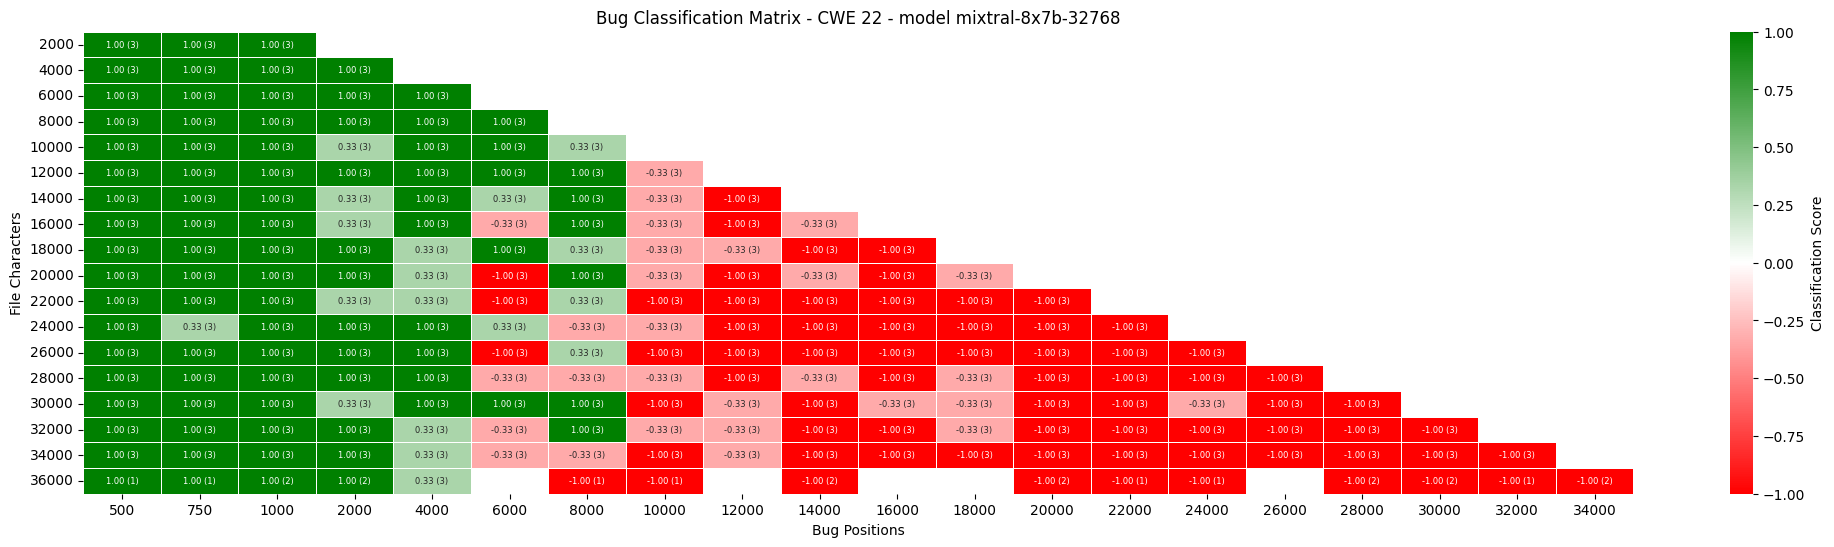

In [674]:
# Create mappings for unique entries
bug_pos_mapping = {val: idx for idx, val in enumerate(sorted(df['target_bug_pos'].unique()))}
file_char_mapping = {val: idx for idx, val in enumerate(sorted(df['target_characters'].unique()))}


# remove all infexes which are not divisible by 1000 from bugs
bug_pos_mapping_filtered = {}
i = 0
for val in sorted(bug_pos_mapping.keys()):  # Ensure the order is maintained
    if val % 2000 == 0 or val <= 1000:
        bug_pos_mapping_filtered[val] = i
        i += 1  # Increment i only when a value is added to the filtered mapping

bug_pos_mapping = bug_pos_mapping_filtered

file_char_mapping_filtered = {}
i = 0
for val in sorted(file_char_mapping.keys()):  # Ensure the order is maintained
    if val % 2000 == 0:
        file_char_mapping_filtered[val] = i
        i += 1

file_char_mapping = file_char_mapping_filtered

# Initialize matrix
bug_depth = len(bug_pos_mapping)
file_depth = len(file_char_mapping)
matrix = [[[] for _ in range(bug_depth)] for _ in range(file_depth)]

# Classification mapping updated for numeric handling
classification_mapping = {'TP': 1, 'FP': -1, 'TN': 0, 'FN': -1}

matrix_values = [[[] for _ in range(bug_depth)] for _ in range(file_depth)]
matrix_annotations = [[None for _ in range(bug_depth)] for _ in range(file_depth)]

colors = [ "red", "white", "green"]  # Blue for -1, Red for 0, Green for 1
nodes = [0.0, 0.5,  1.0]  # Points in the range that correspond to the colors
cmap = mcolors.LinearSegmentedColormap.from_list("", list(zip(nodes, colors)))

# Normalize color mapping from -1 to 1
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Populate the matrix_values with numeric data as before
for _, row in df.iterrows():
    if row['target_bug_pos'] not in bug_pos_mapping or row['target_characters'] not in file_char_mapping:
        continue
    file_idx = file_char_mapping[row['target_characters']]
    bug_idx = bug_pos_mapping[row['target_bug_pos']]
    classification_value = classification_mapping[row['classification']]
    matrix_values[file_idx][bug_idx].append(classification_value)

# Convert matrix_values to averages and populate matrix_annotations with formatted strings
for i in range(file_depth):
    for j in range(bug_depth):
        if matrix_values[i][j]:  # If the list is not empty
            avg = sum(matrix_values[i][j]) / len(matrix_values[i][j])
            count = len(matrix_values[i][j])
            matrix_values[i][j] = avg  # Store average for heatmap color
            matrix_annotations[i][j] = f"{avg:.2f} ({count})"  # Format string for annotation
        else:
            matrix_values[i][j] = np.nan # Use 0 or np.nan for heatmap color if needed
            matrix_annotations[i][j] = None  # Keep annotations empty

# Convert matrix to a numpy array for better handling in seaborn
matrix = np.array(matrix)

# Create labels for axes
bug_labels = sorted(bug_pos_mapping.keys())
file_labels = sorted(file_char_mapping.keys())

# Plotting
plt.figure(figsize=(25,6))
ax = sns.heatmap(matrix_values, cmap=cmap,  norm=norm, linewidths=.5, annot=matrix_annotations,
                 yticklabels=file_labels, xticklabels=bug_labels, cbar_kws={'label': 'Classification Score'},
                 annot_kws={'size': 6}, fmt="")  # `fmt` is set to empty string to handle custom annotations
plt.ylabel('File Characters')
plt.xlabel('Bug Positions')
plt.title(f"Bug Classification Matrix - CWE {CWE} - model {MODEL}")
plt.savefig(f'./plots/heatmap_{CWE}_{MODEL}.png')

plt.show()

Outliers for CWE-22 are below -18336.5 or above 33403.5 30737.700000000044


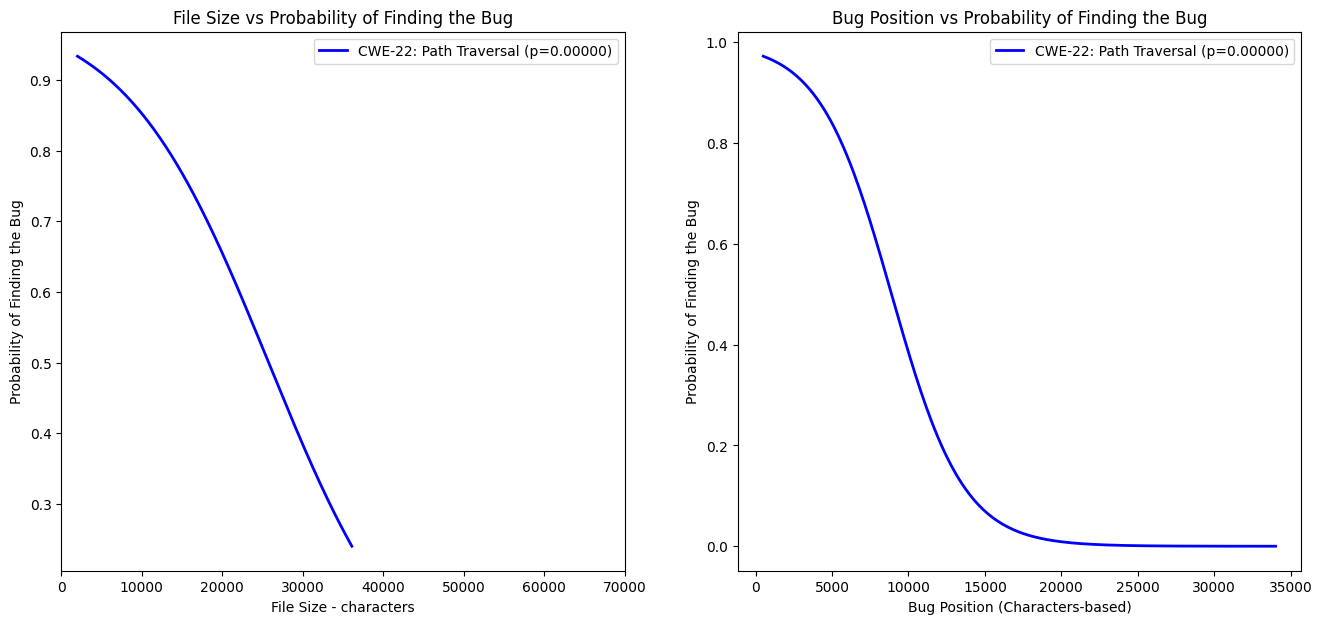

In [675]:
import numpy as np
import statsmodels.api as sm

def calculate_outlier_thresholds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    # Prepare data: Add a constant term for the intercept
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    
    # Fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 suppresses fit information
    
    # Generate predictions for a range of input values
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    x_values_with_const = sm.add_constant(x_values)
    y_probs = model.predict(x_values_with_const)
    label_dict = {
        "CWE-22": "CWE-22: Path Traversal",
        "CWE-89": "CWE-89: SQL Injection",
        "CWE-79": "CWE-79: XSS"
    }

    # Plot
    ax.plot(x_values, y_probs, label=f"{label_dict[label]} (p={model.pvalues[x_col]:.5f})", color=color, linewidth=2)
    
    return model

target_variable = 'classification_TP'
cwe = f'CWE-{CWE}'

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
colors = ['blue', 'orange', 'green']

df = pd.get_dummies(df, columns=['classification'], drop_first=False)

# drop NA for some files (like 1 or 2 files overall)
df = df.dropna(subset=['total_length'])

# filter only TP and FN
df = df[(df['classification_TP'] == 1) | (df['classification_FN'] == 1)]

thresholds = calculate_outlier_thresholds(df['bug_pos'])
print(f"Outliers for {cwe} are below {thresholds[0]} or above {thresholds[1]}", df['bug_pos'].quantile(0.99))
df = df[df['bug_pos'] <= 2*thresholds[1]]

plot_logistic_regression(df, 'total_length', target_variable, cwe, axes[0], colors[0])
plot_logistic_regression(df, 'bug_pos', target_variable, cwe, axes[1], colors[0])

axes[0].set_xlabel('File Size - characters')
axes[0].set_ylabel('Probability of Finding the Bug')
axes[0].set_title('File Size vs Probability of Finding the Bug')
axes[0].set_xlim([0, 70000])
axes[0].legend()

axes[1].set_xlabel('Bug Position (Characters-based)')
axes[1].set_ylabel('Probability of Finding the Bug')
axes[1].set_title('Bug Position vs Probability of Finding the Bug')
axes[1].legend()
# save into plots
plt.savefig(f'./plots/logistic_regression_{CWE}_{MODEL}.png')